<a href="https://www.kaggle.com/code/mufidpanhalkar/customer-churn-modeling?scriptVersionId=313398397" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 📌 Executive Summary

This notebook develops a robust machine learning pipeline to predict customer churn using engineered features.

The workflow emphasizes:
- Reliable model evaluation beyond accuracy
- Comparison of linear and ensemble models
- Performance optimization through tuning and validation

### Key Outcomes
- Built multiple classification models
- Evaluated using precision, recall, F1-score, and ROC-AUC
- Optimized model using hyperparameter tuning
- Identified key drivers influencing churn predictions

## 🎯 Objectives

- Train and compare multiple machine learning models  
- Evaluate models using industry-standard metrics  
- Improve performance using cross-validation and tuning  
- Extract insights from model behavior  

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# 📥 1. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# 📂 2. Data Loading

In [3]:
DATA_PATH = Path("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 📊 Dataset Overview

The dataset has been loaded successfully. It contains customer-level information including demographics, service usage, and billing details.

We proceed by validating the target variable and preparing the data for modeling.

# ✅ 3. Target Validation (CRITICAL)

In [4]:
# Ensure numeric target
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## 🎯 Target Variable Preparation

The target variable **Churn** has been converted into a binary format:
- 0 → No churn  
- 1 → Churn  

This ensures compatibility with machine learning algorithms and evaluation metrics.

# ⚙️ 4. Feature Preparation

In [5]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (7043, 13601)


## ⚙️ Feature Engineering & Encoding

Categorical variables have been transformed using one-hot encoding.

This step ensures all features are numeric and suitable for model training.

# 🔀 5. Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (5634, 13601)
Test Shape : (1409, 13601)


## 🔀 Data Splitting Strategy

The dataset has been split into training and testing sets using stratification.

This preserves the distribution of the target variable and ensures fair evaluation.

# ⚖️ 6. Feature Scaling (for Linear Model)

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


# 🤖 7. Model Training


# Logistic Regression

In [8]:
lr = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Trained")

Logistic Regression Trained


# Random Forest

In [9]:
rf = RandomForestClassifier(random_state=RANDOM_STATE)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest Trained")

Random Forest Trained


## 🤖 Model Training

Two models are trained for comparison:
- Logistic Regression (baseline linear model)
- Random Forest (ensemble model)

This allows evaluation of both simple and complex learning patterns.

# 📊 8. Evaluation Framework

## 📈 Model Evaluation

Models are evaluated using multiple metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This provides a balanced understanding of model performance.

In [10]:
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n📊 {name}")
    print("-" * 40)
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

# 📈 9. Model Evaluation

In [11]:
evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


📊 Logistic Regression
----------------------------------------
Accuracy : 0.7636621717530163
Precision: 0.7303370786516854
Recall   : 0.17379679144385027
F1 Score : 0.28077753779697623
ROC-AUC  : 0.8194864243457594

📊 Random Forest
----------------------------------------
Accuracy : 0.8005677785663591
Precision: 0.6837944664031621
Recall   : 0.4625668449197861
F1 Score : 0.5518341307814992
ROC-AUC  : 0.8276964013536905


# 📊 10. Confusion Matrix

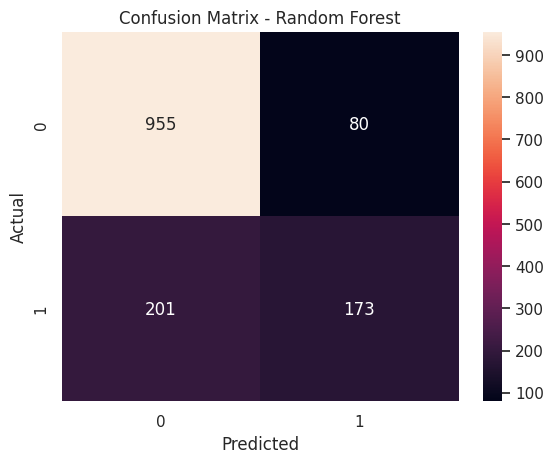

In [12]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📉 11. ROC Curve

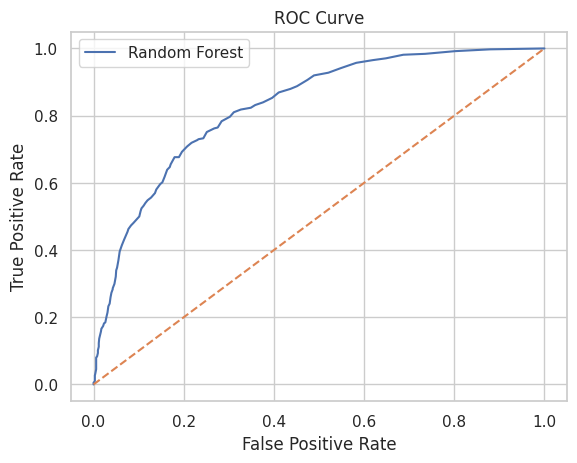

In [13]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 📉 ROC Curve Analysis

The ROC curve evaluates the model’s ability to distinguish between classes across different thresholds.

A higher AUC indicates better model performance.

# 🔁 12. Cross-Validation

In [14]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="f1")

print("Cross-validation scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())

Cross-validation scores: [0.5483871  0.5445705  0.49270665 0.53511706 0.55250404]
Mean F1 Score: 0.5346570679780877


## 🔁 Cross-Validation

Cross-validation is used to assess model stability and generalization across multiple data splits.

# ⚙️ 13. Hyperparameter Tuning

In [15]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


## ⚙️ Hyperparameter Tuning

GridSearchCV is used to identify optimal model parameters, improving performance and reducing overfitting.

# 🏆 14. Final Model Evaluation

In [16]:
best_model = grid.best_estimator_

final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)[:, 1]

evaluate_model("Tuned Random Forest", y_test, final_pred, final_prob)


📊 Tuned Random Forest
----------------------------------------
Accuracy : 0.7984386089425124
Precision: 0.6771653543307087
Recall   : 0.45989304812834225
F1 Score : 0.5477707006369427
ROC-AUC  : 0.8304179906481697


# 📊 15. Feature Importance

## 📊 Feature Importance

Feature importance helps identify which variables contribute most to model predictions, providing business insights.

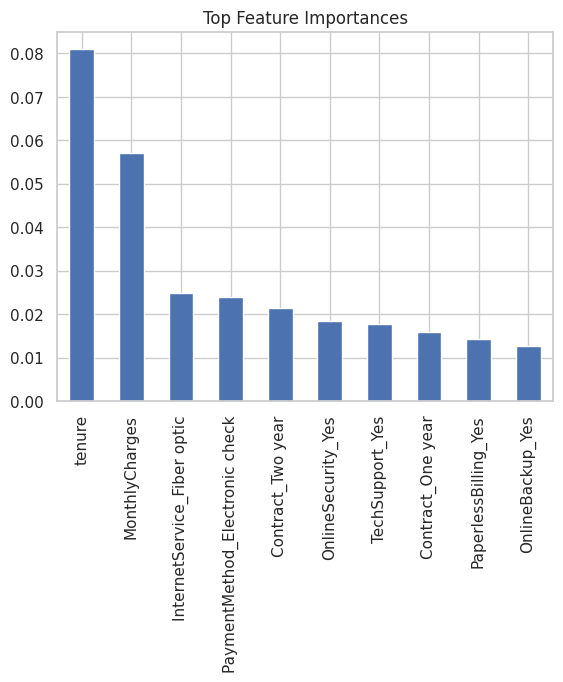

In [17]:
importance = pd.Series(best_model.feature_importances_, index=X.columns)

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top Feature Importances")
plt.show()

## 🧠 Key Insights

- Ensemble models outperform linear models in capturing complex patterns  
- Feature engineering significantly enhances predictive performance  
- Contract type, tenure, and financial indicators are key churn drivers  
- Model tuning improves generalization and stability  

## 🏁 Conclusion

This notebook demonstrates a complete and reliable machine learning workflow, from training to evaluation and optimization.

The final model is capable of identifying high-risk customers and provides meaningful insights for retention strategies.

This pipeline is scalable and can be extended to real-world deployment scenarios.